<a href="https://colab.research.google.com/github/kris-gaudel/pinn/blob/main/models/lagrangian_nn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Lagrangian Neural Networks (LNNs) - Solving the double pendulum equation


In [ ]:
!pip install jax
!pip install optax
!pip install equinox

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.1/182.1 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 3.6 MB/s eta 0:00:00


#### The Lagrangian and numerical solution for the double-pendulum problem
Suppose we are given a a double pendulum with angles $\theta_1$ and $\theta_2$, with respective rods of length $L_1$ and $L_2$

The state vector of the double pendulum is denoted
$$
y =
\begin{bmatrix}
\theta_1 \\
\theta_2 \\
\dot{\theta_1} \\
\dot{\theta_2} \\
\end{bmatrix}, \dot{y} = \frac{dy}{dt}
$$
where $\theta_i$ is the angle of the i'th rod and the downward axis.

Let $\theta$ and $\dot{\theta}$ be the vectors of the angles and their derivatives respectively

We now define the Lagrangian
$$
L(\theta, \dot{\theta}) = T(\theta, \dot{\theta}) - V(\theta)
$$

For the double pendulum, we have
$$
T(\theta, \dot{\theta}) = \frac{1}{2} {\dot{\theta}}^T M(\theta)\dot{\theta} \\
V(\theta) = -(m_1+m_2)gL_1\cos(\theta_1) - m_2 g L_2 \cos(\theta_2) \\
M(\theta)=\begin{bmatrix}
(m_1+m_2)L_1^2 & m_2L_1L_2\cos(\theta_1-\theta_2) \\
m_2L_1L_2\cos(\theta_1-\theta_2) & m_2L_2^2
\end{bmatrix}
$$

Now recall the Euler-Lagrange equation
$$
\frac{d}{dt}(\frac{\partial L}{\partial \dot{\theta}}) - \frac{\partial L}{\partial \theta} = 0
$$

Since $V$ does not depend on $\dot{\theta}$, we get
$$
\frac{\partial L}{\partial \dot{\theta}} = \frac{\partial T}{\partial \dot{\theta}} = M(\theta)\dot{\theta}
$$

after some manipulation
$$
\frac{d}{dt} (M(\theta)\dot{\theta}) = M(\theta)\dot{\dot{\theta}} + \dot{M(\theta)}\dot\theta = b(\theta, \dot{\theta}) + \dot{M(\theta)}\dot\theta
$$

The formula for $b(\theta, \dot{\theta})$ is
$$
\Delta=\theta_1-\theta_2 \\
b(\theta,\dot{\theta})=
\begin{bmatrix}
-m_2L_1L_2\sin(\Delta)\dot{\theta}_2^2-(m_1+m_2)gL_1\sin(\theta_1) \\
m_2L_1L_2\sin(\Delta)\dot{\theta}_1^2-m_2gL_2\sin(\theta_2)
\end{bmatrix}
$$

Using some linear algebra, we finally get
$$
\dot{\dot{\theta}} = M(\theta)^{-1}b(\theta, \dot{\theta})
$$

We now have what we need to implement a numerical solver!


In [ ]:
import jax
import jax.numpy as jnp

def M_mat(theta1, theta2, m1, m2, L1, L2):
  c = jnp.cos(theta1 - theta2)
  return jnp.array([
      [(m1 + m2) * L1**2, m2 * L1 * L2 * c],
      [m2 * L1 * L2 * c, m2 * L2**2],
  ])

def b_vec(theta1, theta2, dtheta1, dtheta2, m1, m2, L1, L2, g):
  s = jnp.sin(theta1 - theta2)
  return jnp.array([
      -m2 * L1 * L2 * s * (dtheta2**2) - (m1 + m2) * g * L1 * jnp.sin(theta1),
        m2 * L1 * L2 * s * (dtheta1**2) - m2 * g * L2 * jnp.sin(theta2),
  ])


In [ ]:
# y_dot = f(y)
def double_pendulum_rhs(y, params):
  m1, m2, L1, L2, g = params
  theta1, theta2, dtheta1, dtheta2 = y

  M = M_mat(theta1, theta2, m1, m2, L1, L2)
  b = b_vec(theta1, theta2, dtheta1, dtheta2, m1, m2, L1, L2, g)

  ddtheta = jnp.linalg.solve(M, b) # double dot theta

  return jnp.array([dtheta1, dtheta2, ddtheta[0], ddtheta[1]])

# RK4 Step
def rk4_step(y, params, dt):
  k1 = double_pendulum_rhs(y, params)
  k2 = double_pendulum_rhs(y + 0.5 * dt * k1, params)
  k3 = double_pendulum_rhs(y + 0.5 * dt * k2, params)
  k4 = double_pendulum_rhs(y + dt * k3, params)
  return y + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

# Rollout for lax.scan
def rollout(y0, params, dt, steps):
  def body(y, _):
      y_next = rk4_step(y, params, dt)
      return y_next, y_next

  yT, ys = jax.lax.scan(body, y0, xs=None, length=steps)
  ys = jnp.vstack([y0[None, :], ys])
  return ys

def angles_to_xy(ys, params):
  _, _, L1, L2, _ = params
  theta1 = ys[:, 0]
  theta2 = ys[:, 1]

  x1 = L1 * jnp.sin(theta1)
  y1 = -L1 * jnp.cos(theta1)

  x2 = x1 + L2 * jnp.sin(theta2)
  y2 = y1 - L2 * jnp.cos(theta2)

  return x1, y1, x2, y2

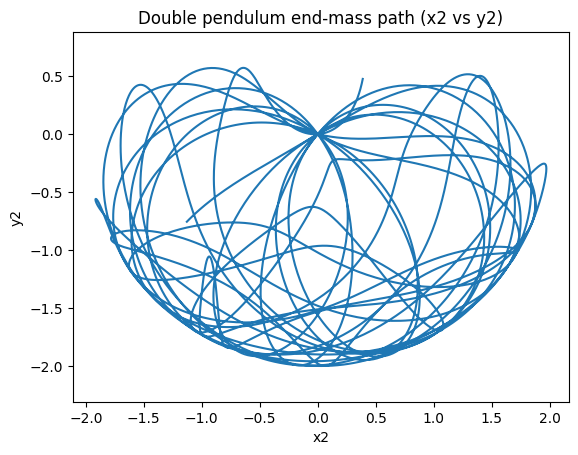

In [ ]:
import matplotlib.pyplot as plt

params = (5.0, 1.0, 1.0, 1.0, 9.81)  # (m1,m2,L1,L2,g)

# y0 = [theta1, theta2, dtheta1, dtheta2]
y0 = jnp.array([1.2, 10.0, 0.0, 0.0])

dt = 0.005
steps = 6000

ys = rollout(y0, params, dt, steps)
x1, y1, x2, y2 = angles_to_xy(ys, params)

plt.figure()
plt.plot(jnp.asarray(x2), jnp.asarray(y2))
plt.title("Double pendulum end-mass path (x2 vs y2)")
plt.xlabel("x2")
plt.ylabel("y2")
plt.axis("equal")
plt.show()

## Implementing the Lagrangian Neural Net
The idea of the LNN is simple, instead of solving for $\dot{\dot{\theta}}$, we train a neural net $L_{\phi}(\theta, \dot{\theta}) \in \mathbb{R}$ ($\phi$ are the parameters to the network) that acts as our scalar Lagrangian. This value is then used to derive $\dot{\dot{\theta}}$.

The data generation process I follow is a bit different than the paper, instead of taking many samples of "points" of trajectories, I generate fewer full trajectories and use that instead.

Let's start by generating a dataset for testing from our numerical solver

In [ ]:
import jax
import jax.numpy as jnp


def traj_to_dataset(ys, params):
  """
  Convert a single trajectory into supervised samples
  """
  ydot = jax.vmap(lambda y: double_pendulum_rhs(y, params))(ys)   # (T, 4)
  X = ys
  Y = ydot[:, 2:4]
  return X, Y


def sample_y0s(key, n_traj, theta_range=jnp.pi, dtheta_range=1.0):
  """
  Sample random initial conditions
  """
  k1, k2 = jax.random.split(key)
  thetas = jax.random.uniform(
      k1, (n_traj, 2), minval=-theta_range, maxval=theta_range
  )
  dthetas = jax.random.uniform(
      k2, (n_traj, 2), minval=-dtheta_range, maxval=dtheta_range
  )
  return jnp.concatenate([thetas, dthetas], axis=1)


def rollout_batch(y0s, params, dt, steps):
  """
  Roll out a batch of trajectories
  """
  return jax.vmap(lambda y0: rollout(y0, params, dt, steps))(y0s)


def preprocess_trajectories(ys_batch, subsample=1, drop_first=0):
  """
  Apply time slicing to reduce temporal correlation
  """
  return ys_batch[:, drop_first::subsample, :]


def trajectories_to_dataset(ys_batch, params):
  """
  Convert a batch of trajectories into a flat supervised dataset
  """
  X_batch, Y_batch = jax.vmap(lambda ys: traj_to_dataset(ys, params))(ys_batch)
  X = X_batch.reshape(-1, 4)
  Y = Y_batch.reshape(-1, 2)
  return X, Y


def make_trajectory_dataset_split(
    key,
    params,
    dt,
    steps,
    n_traj,
    train_frac=0.9,
    theta_range=jnp.pi,
    dtheta_range=1.0,
    subsample=2,
    drop_first=0,
):
  """
  Generate train/val datasets by splitting at the trajectory level

  This avoids leakage where states from the same trajectory appear
  in both train and validation sets
  """
  k_init, k_perm = jax.random.split(key)

  # 1) Sample all initial conditions
  y0s = sample_y0s(
      k_init,
      n_traj,
      theta_range=theta_range,
      dtheta_range=dtheta_range,
  )

  # 2) Shuffle trajectories, then split by trajectory
  perm = jax.random.permutation(k_perm, n_traj)
  y0s = y0s[perm]

  n_train = int(train_frac * n_traj)
  y0s_tr = y0s[:n_train]
  y0s_va = y0s[n_train:]

  # 3) Roll out train/val trajectories separately
  ys_tr = rollout_batch(y0s_tr, params, dt, steps)
  ys_va = rollout_batch(y0s_va, params, dt, steps)

  # 4) Drop initial transient + subsample in time
  ys_tr = preprocess_trajectories(ys_tr, subsample=subsample, drop_first=drop_first)
  ys_va = preprocess_trajectories(ys_va, subsample=subsample, drop_first=drop_first)

  # 5) Convert to flat supervised datasets
  Xtr, Ytr = trajectories_to_dataset(ys_tr, params)
  Xva, Yva = trajectories_to_dataset(ys_va, params)

  return (Xtr, Ytr), (Xva, Yva)

In [ ]:
params = (5.0, 1.0, 1.0, 1.0, 9.81)
dt = 0.005
steps = 2000
n_traj = 256

key = jax.random.PRNGKey(0)

(Xtr, Ytr), (Xva, Yva) = make_trajectory_dataset_split(
    key,
    params,
    dt,
    steps,
    n_traj,
    train_frac=0.9,
    theta_range=jnp.pi,
    dtheta_range=1.0,
    subsample=2,
    drop_first=10,
)

print("Train:", Xtr.shape, Ytr.shape)
print("Val:  ", Xva.shape, Yva.shape)
print("Example X row:", Xtr[0])
print("Example Y row:", Ytr[0])

Train: (229080, 4) (229080, 2)
Val:   (25896, 4) (25896, 2)
Example X row: [-0.2649581  -1.5703743  -0.62717134  0.6475974 ]
Example Y row: [2.0799153 9.644061 ]


In [ ]:
import equinox as eqx
import optax

class LagrangianMLP(eqx.Module):
    layers: list

    def __init__(self, key, in_size=4, width=128, depth=3):
      keys = jax.random.split(key, depth + 1)

      layers = []
      last_size = in_size

      for i in range(depth):
          layers.append(eqx.nn.Linear(last_size, width, key=keys[i]))
          last_size = width

      layers.append(eqx.nn.Linear(last_size, 1, key=keys[-1]))
      self.layers = layers

    def __call__(self, x):
      z = x
      for layer in self.layers[:-1]:
          z = jax.nn.softplus(layer(z))
      out = self.layers[-1](z)
      return out.squeeze()

In [ ]:
def split_state(x):
  q = x[:2]
  qdot = x[2:]
  return q, qdot


def lagrangian_fn(model, q, qdot):
  x = jnp.concatenate([q, qdot], axis=0)
  return model(x)


def qddot_from_lagrangian(model, x, eps=1e-6):
  """
  x: shape (4,) = [q1, q2, q1dot, q2dot]
  returns: shape (2,) = predicted accelerations
  """
  q, qdot = split_state(x)

  # scalar function L(q, qdot)
  def L(q_, qdot_):
      return lagrangian_fn(model, q_, qdot_)

  # dL/dq
  dLdq = jax.grad(L, argnums=0)(q, qdot)   # shape (2,)

  # Hessian wrt qdot: d^2L / d(qdot)^2
  d2Ldqdot2 = jax.hessian(L, argnums=1)(q, qdot)   # shape (2,2)

  # Mixed term: d/dq [dL/dqdot]
  # shape (2,2), where entry [i,j] = ∂²L / ∂q_j ∂qdot_i
  def dLdqdot(q_):
      return jax.grad(L, argnums=1)(q_, qdot)

  d2Ldqdqdot = jax.jacobian(dLdqdot)(q)   # shape (2,2)

  # small regularization helps numerical stability
  mass_like = d2Ldqdot2 + eps * jnp.eye(q.shape[0])

  # use pseudoinverse as in the paper
  qddot = jnp.linalg.pinv(mass_like) @ (dLdq - d2Ldqdqdot @ qdot)
  return qddot

In [ ]:
batched_qddot = jax.vmap(qddot_from_lagrangian, in_axes=(None, 0))

def mse_loss(model, X, Y):
  Yhat = batched_qddot(model, X)
  return jnp.mean((Yhat - Y) ** 2)

In [ ]:
def make_optimizer(lr=1e-3):
  return optax.adam(lr)


@eqx.filter_value_and_grad
def loss_fn(model, X, Y):
  return mse_loss(model, X, Y)


@eqx.filter_jit
def train_step(model, opt_state, Xbatch, Ybatch, optimizer):
  loss, grads = loss_fn(model, Xbatch, Ybatch)
  updates, opt_state = optimizer.update(grads, opt_state, model)
  model = eqx.apply_updates(model, updates)
  return model, opt_state, loss


@eqx.filter_jit
def eval_step(model, X, Y):
  return mse_loss(model, X, Y)


def make_batches(X, Y, batch_size, key):
  n = X.shape[0]
  perm = jax.random.permutation(key, n)
  X = X[perm]
  Y = Y[perm]

  batches = []
  for i in range(0, n, batch_size):
      xb = X[i:i + batch_size]
      yb = Y[i:i + batch_size]
      if xb.shape[0] == batch_size:
          batches.append((xb, yb))
  return batches

In [ ]:
def train_lnn(
    model,
    Xtr, Ytr,
    Xva, Yva,
    key,
    epochs=50,
    batch_size=32,
    lr=1e-3
):
    optimizer = make_optimizer(lr)
    opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        key, subkey = jax.random.split(key)
        batches = make_batches(Xtr, Ytr, batch_size, subkey)

        epoch_loss = 0.0
        for xb, yb in batches:
            model, opt_state, loss = train_step(model, opt_state, xb, yb, optimizer)
            epoch_loss += loss

        epoch_loss = epoch_loss / len(batches)
        val_loss = eval_step(model, Xva, Yva)

        train_losses.append(epoch_loss)
        val_losses.append(val_loss)

        if epoch % 5 == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch:03d} | train={float(epoch_loss):.6f} | val={float(val_loss):.6f}")

    return model, jnp.array(train_losses), jnp.array(val_losses)

In [ ]:
model_key, train_key = jax.random.split(jax.random.PRNGKey(42))

model = LagrangianMLP(
    key=model_key,
    in_size=4,
    width=128,   # paper does 500
    depth=3
)

model, train_losses, val_losses = train_lnn(
    model,
    Xtr, Ytr,
    Xva, Yva,
    key=train_key,
    epochs=50,
    batch_size=32,
    lr=1e-3
)

Epoch 000 | train=45425.929688 | val=345.436127
Epoch 005 | train=126.013649 | val=104.932137
Epoch 010 | train=114.162422 | val=87.399185
Epoch 015 | train=64.338173 | val=65.419479
Epoch 020 | train=43.806908 | val=35.954254
Epoch 025 | train=33.866081 | val=27.193939
Epoch 030 | train=31.043427 | val=27.952299
Epoch 035 | train=30.937967 | val=25.414524
Epoch 040 | train=37.715527 | val=28.239948
Epoch 045 | train=29.415558 | val=23.498756
Epoch 049 | train=36.985920 | val=25.584906


In [ ]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt


def learned_rhs(model, x):
    """
    x = [theta1, theta2, dtheta1, dtheta2]
    returns xdot = [dtheta1, dtheta2, ddtheta1, ddtheta2]
    """
    qdot = x[2:]
    qddot = qddot_from_lagrangian(model, x)
    return jnp.concatenate([qdot, qddot], axis=0)


def learned_rk4_step(model, x, dt):
    k1 = learned_rhs(model, x)
    k2 = learned_rhs(model, x + 0.5 * dt * k1)
    k3 = learned_rhs(model, x + 0.5 * dt * k2)
    k4 = learned_rhs(model, x + dt * k3)
    return x + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)


def learned_rollout(model, x0, dt, steps):
    """
    Roll out the learned LNN dynamics from x0.
    Returns shape (steps+1, 4), including x0.
    """
    def body(x, _):
        x_next = learned_rk4_step(model, x, dt)
        return x_next, x_next

    _, xs = jax.lax.scan(body, x0, xs=None, length=steps)
    xs = jnp.vstack([x0[None, :], xs])
    return xs

In [ ]:
x0 = Xva[0]
steps_viz = 1000

true_traj = rollout(x0, params, dt, steps_viz)
pred_traj = learned_rollout(model, x0, dt, steps_viz)

print(true_traj.shape, pred_traj.shape)
print("Initial state:", x0)

(1001, 4) (1001, 4)
Initial state: [-0.46890572  0.72767264  0.78363276 -0.96144515]


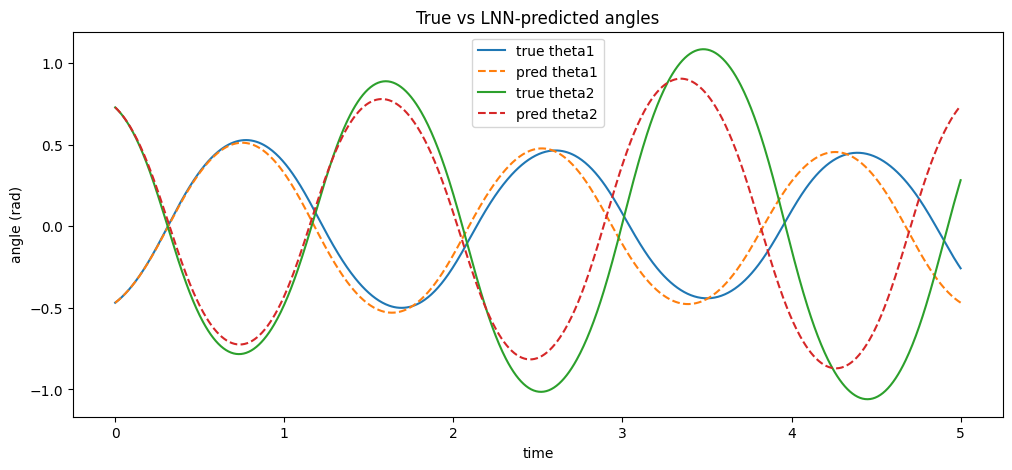

In [ ]:
t = jnp.arange(steps_viz + 1) * dt

plt.figure(figsize=(12, 5))
plt.plot(t, true_traj[:, 0], label="true theta1")
plt.plot(t, pred_traj[:, 0], "--", label="pred theta1")
plt.plot(t, true_traj[:, 1], label="true theta2")
plt.plot(t, pred_traj[:, 1], "--", label="pred theta2")
plt.xlabel("time")
plt.ylabel("angle (rad)")
plt.title("True vs LNN-predicted angles")
plt.legend()
plt.show()

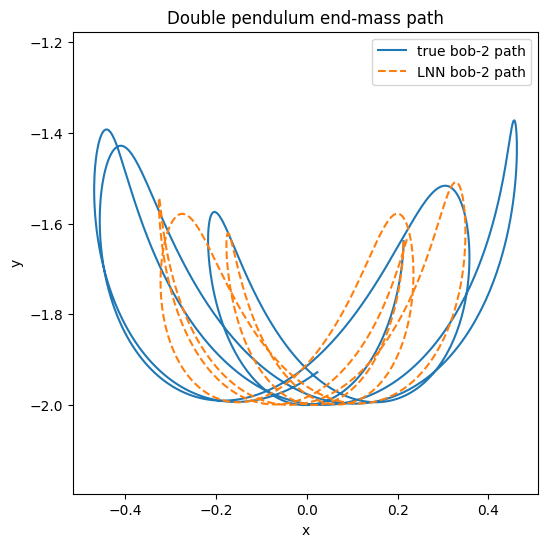

In [ ]:
x1_true, y1_true, x2_true, y2_true = angles_to_xy(true_traj, params)
x1_pred, y1_pred, x2_pred, y2_pred = angles_to_xy(pred_traj, params)

plt.figure(figsize=(6, 6))
plt.plot(x2_true, y2_true, label="true bob-2 path")
plt.plot(x2_pred, y2_pred, "--", label="LNN bob-2 path")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Double pendulum end-mass path")
plt.axis("equal")
plt.legend()
plt.show()